Lable Encoding

- Goal  - turn categorical (non-numeric) data into numbers .
-  ML models eat numbers and produce numbers.

Encoding Technique

  - Label encoding
  - ordinal encoding
  - one- hot encoding
  - binary encoding
  - Target(mean) encoding
  - Frequency / count encoding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing  import LabelEncoder, OrdinalEncoder, OneHotEncoder
pd.set_option('display.max_columns',None)


# Toy Dataset

  - color     - nominal  - no order
  - size      - ordinal   S < M < L < XL
  - city      - nominal but high cardinality - many possible values
  - purchase   -1/0

In [ ]:
df = pd.DataFrame({
    "color": ['Red','Green','Blue','Green','Red','Blue','Red','Green'],
    'size' :  ['S','L','M','XL','M','S','L','M'],
    'city' :  ['Mumbai','Delhi','Chennai','Mumbai','Delhi','Mumbai','Chennai','Mumbai'],

    'purchased':[1,0,1,0,1,1,0,1]
})

df

,color,size,city,purchased
0,Red,S,Mumbai,1
1,Green,L,Delhi,0
2,Blue,M,Chennai,1
3,Green,XL,Mumbai,0
4,Red,M,Delhi,1
5,Blue,S,Mumbai,1
6,Red,L,Chennai,0
7,Green,M,Mumbai,1


In [ ]:
print('No of rows and columns',df.shape[0],df.shape[1])

No of rows and columns 8 4


In [ ]:
for column in df.columns:
  print('Number of unique values' , column,  df[column].nunique())

Number of unique values color 3
Number of unique values size 4
Number of unique values city 3
Number of unique values purchased 2


In [ ]:
for column in df.columns:
  print(' unique values' , column,  df[column].unique())

 unique values color ['Red' 'Green' 'Blue']
 unique values size ['S' 'L' 'M' 'XL']
 unique values city ['Mumbai' 'Delhi' 'Chennai']
 unique values purchased [1 0]


1 . Label Encoding

##### it is simplest technique where each unique category is assigned a integer (usually alphabetically)

    -  Blue -> 0  , Green -> 1 , Red -> 2
    - this fast and memory light - it stays in single column

In [ ]:
le = LabelEncoder()
df_label = df.copy()
df_label['encoded_color']= le.fit_transform(df['color'])
# see mapping the  encoder chose
print('Label encoded classes',le.classes_)
mapping = dict (zip(le.classes_, le.transform(le.classes_)))
print(mapping)
df_label[['color','encoded_color']]

Label encoded classes ['Blue' 'Green' 'Red']
{'Blue': np.int64(0), 'Green': np.int64(1), 'Red': np.int64(2)}


,color,encoded_color
0,Red,2
1,Green,1
2,Blue,0
3,Green,1
4,Red,2
5,Blue,0
6,Red,2
7,Green,1


The trap : accidental order

- the model see number and  assumes red(2)  > geen (1) > blue (0)
- for color it doesnt make sense .Giving this to linear or neural network inject
  false ranking
#### Safe to use when
     -  its encoding  the target (y)  
    - if tree based models (decision tree , random forest , xgboost etc)
     they split data on threshold and dont care about fake ordering
    
- avoid for nominal features going to linear model / neural network. Use one hot encoding

# 2 Ordinal Encoding
   - it is similar to label encoding - one column of integers
   - here the order is intentional and real
   - define the sequence instead of letting the encoder guess alphabetically

   - size is ordered  S < M < L < XL

In [ ]:
size_orders=["S","M","L","XL"]  # WE decide meaniful order
oe = OrdinalEncoder(categories=[size_orders])
df_ord = df.copy()
df_ord["encoded_size"]= oe.fit_transform(df[['size']]).astype(int)
df_ord

,color,size,city,purchased,encoded_size
0,Red,S,Mumbai,1,0
1,Green,L,Delhi,0,2
2,Blue,M,Chennai,1,1
3,Green,XL,Mumbai,0,3
4,Red,M,Delhi,1,1
5,Blue,S,Mumbai,1,0
6,Red,L,Chennai,0,2
7,Green,M,Mumbai,1,1


In [ ]:
df_ord[['size','encoded_size']].drop_duplicates().sort_values('encoded_size')

,size,encoded_size
0,S,0
2,M,1
1,L,2
3,XL,3


#  3. One Hot Encoding
   
    - this cure the false order problem.
    - Instead of one numbered column
    - It will create a separate binary(0/1) column per category
    - No category is bigger than another
    - Each category get a yes/no flag

In [ ]:
# through pandas
one_hot_encoding = pd.get_dummies(df.color,prefix='color').astype(int)
one_hot_encoding

,color_Blue,color_Green,color_Red
0,0,0,1
1,0,1,0
2,1,0,0
3,0,1,0
4,0,0,1
5,1,0,0
6,0,0,1
7,0,1,0


#### Dummy encoding - drop one column

In [ ]:
one_hot_encoding1 = pd.get_dummies(df.color,prefix='color',drop_first=True).astype(int)
one_hot_encoding1

,color_Green,color_Red
0,0,1
1,1,0
2,0,0
3,1,0
4,0,1
5,0,0
6,0,1
7,1,0


In [ ]:
# the scikit way
encoder =OneHotEncoder(sparse_output=False,dtype=int)
arr = encoder.fit_transform(df[['color']])
pd.DataFrame(arr,columns=encoder.get_feature_names_out(['color']))

,color_Blue,color_Green,color_Red
0,0,0,1
1,0,1,0
2,1,0,0
3,0,1,0
4,0,0,1
5,1,0,0
6,0,0,1
7,0,1,0


## The trap :  dimensionality explosion

  -  A column with 1000 unique values becomes 1000 new columns
  -  training slow and model overfit. this is the curse of dimensionality
  
- Use one hot encoding when the no of categories is small  - (rule of thumb - under 10 to 15)

- For higher cadinality feature use Binary or frequency encoding


# 4. Binary Encoding

A clever middle ground for many categorties

- Steps:
    -  1. Assign  each category a number
    -  2. convert that integer into binary
    -  3. Spread the digits across few columns

- 7 categories need  7 one hot columns
- if we use binary we need 3 binary columns  since 2 **3 =8
- big saving while we still avoid most of false ordering problem .

Scratch implementation of BinaryEncoders


In [ ]:
#  Banglore 1   Chennai 2  Delhi  3  Mumbai 4
#  step  convert int to binary     Bangalore   1    001      Chennai   2   010   Delhi 3  011   Mumbai  4   100
# step 3
'''
    City                B0          B1       B2
    Bangalore            0          0        1
    Chennai              0          1        0
    Delhi                0          1        1
    Mumbai               1          0        0

Number of  columns  = [log2(N)]

'''

' \n    City                B0          B1       B2\n    Bangalore            0          0        1\n    Chennai              0          1        0\n    Delhi                0          1        1\n    Mumbai               1          0        0\n\nNumber of  columns  = [log2(N)]\n\n'

In [ ]:
def binary_encod(series,prefix):

  cats1 = sorted(series.unique())
  #print(cats1)
  codes =  {c : i+1 for i, c in enumerate(cats1)}  # 1 index integers
  n_bits= max (1,int(np.ceil(np.log2(len(cats1)+1))))  # columns needed
  rows=[]
  #print(codes)
  for val in series:
    bits = format(codes[val],f'0{n_bits}b')   # int into binary
    rows.append(int(b)  for b in bits)
  cols = [f"{prefix}_bit{i}" for i in range(n_bits)]
  return pd.DataFrame(rows,columns=cols,index = series.index),codes



In [ ]:
bin_df,codes = binary_encod(df["city"],'city')
print('Integer codes',codes)
pd.concat([df['city'], bin_df], axis=1)

Integer codes {'Chennai': 1, 'Delhi': 2, 'Mumbai': 3}


,city,city_bit0,city_bit1
0,Mumbai,1,1
1,Delhi,1,0
2,Chennai,0,1
3,Mumbai,1,1
4,Delhi,1,0
5,Mumbai,1,1
6,Chennai,0,1
7,Mumbai,1,1


In [ ]:
df["city"]

,city
0,Mumbai
1,Delhi
2,Chennai
3,Mumbai
4,Delhi
5,Mumbai
6,Chennai
7,Mumbai


In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
import category_encoders as ce
encoders = ce.BinaryEncoder()
encoded_df= encoder.fit_transform(df[['city']])
cols=['city1','city2','city3']
df_binary=pd.DataFrame(encoded_df,columns=cols)
df_binary

,city1,city2,city3
0,0,0,1
1,0,1,0
2,1,0,0
3,0,0,1
4,0,1,0
5,0,0,1
6,1,0,0
7,0,0,1


# rule of thumb

no of unique categores                       encoder

  - 2-10                                         one hot encoding
  - 10-100                                        one hot or binary
  -  gt 100                                        binary or target encoding
  - ordered cat                                  ordinal encoding


# 5. Target (Mean ) Encoding
       - replace each category with the average taget value from that category.
       - it packs predicative signal directly into the feature and stays
        a single compact column regardless of cardinaliy

In [ ]:
df

,color,size,city,purchased
0,Red,S,Mumbai,1
1,Green,L,Delhi,0
2,Blue,M,Chennai,1
3,Green,XL,Mumbai,0
4,Red,M,Delhi,1
5,Blue,S,Mumbai,1
6,Red,L,Chennai,0
7,Green,M,Mumbai,1


In [ ]:
group = df.groupby("city")["purchased"]
group.groups

{'Chennai': [2, 6], 'Delhi': [1, 4], 'Mumbai': [0, 3, 5, 7]}

In [ ]:
city_means = df.groupby("city")["purchased"].mean()
print(city_means)

city
Chennai    0.50
Delhi      0.50
Mumbai     0.75
Name: purchased, dtype: float64


In [ ]:
df_taget=df.copy()
df_taget["city_target_encoding"]= df["city"].map(city_means)
df_taget[["city","city_target_encoding","purchased"]]

,city,city_target_encoding,purchased
0,Mumbai,0.75,1
1,Delhi,0.50,0
2,Chennai,0.50,1
3,Mumbai,0.75,0
4,Delhi,0.50,1
5,Mumbai,0.75,1
6,Chennai,0.50,0
7,Mumbai,0.75,1


# the problem : data leakage

- we built the feauture using the target , so the model can peek at the ans and overfit.

- worse a category that appears once gets an encoding of excatly its own label -pure leakage

Solution : always do in real world project

  - Smoothing -> blend the category mean with the global mean so rare category dont dominate.

  - cross validation / out -of-fold encoding


In [ ]:
def smoother_target_encode(df,col,target,m=2.0):
  global_mean = df[target].mean()
  agg =df.groupby(col)[target].agg(['mean','count'])
  # weighted blend : large categories trust their own mean , rare one lean to global
  smooth= (agg['count'] * agg["mean"] + m *global_mean)/(agg["count"]+m)
  return df[col].map(smooth)

df_taget["city_smoothed"] = smoother_target_encode(df,"city","purchased")
df_taget


,color,size,city,purchased,city_target_encoding,city_smoothed
0,Red,S,Mumbai,1,0.75,0.708333
1,Green,L,Delhi,0,0.50,0.562500
2,Blue,M,Chennai,1,0.50,0.562500
3,Green,XL,Mumbai,0,0.75,0.708333
4,Red,M,Delhi,1,0.50,0.562500
5,Blue,S,Mumbai,1,0.75,0.708333
6,Red,L,Chennai,0,0.50,0.562500
7,Green,M,Mumbai,1,0.75,0.708333


# 6. Frequency / Count Encoding
  
  - replace each category with how often it appears
  

In [ ]:
counts =df['city'].value_counts()
print(counts)
df_freq=df.copy()
df_freq["city_count_enc"] = df['city'].map(counts)   # raw count
df_freq["city_freq_enc"] = df['city'].map(counts / len(df)) # proportion
df_freq[["city","city_count_enc","city_freq_enc"]].drop_duplicates()


city
Mumbai     4
Delhi      2
Chennai    2
Name: count, dtype: int64


,city,city_count_enc,city_freq_enc
0,Mumbai,4,0.50
1,Delhi,2,0.25
2,Chennai,2,0.25


In [ ]:
#  rarely the only encoding style you had rely on

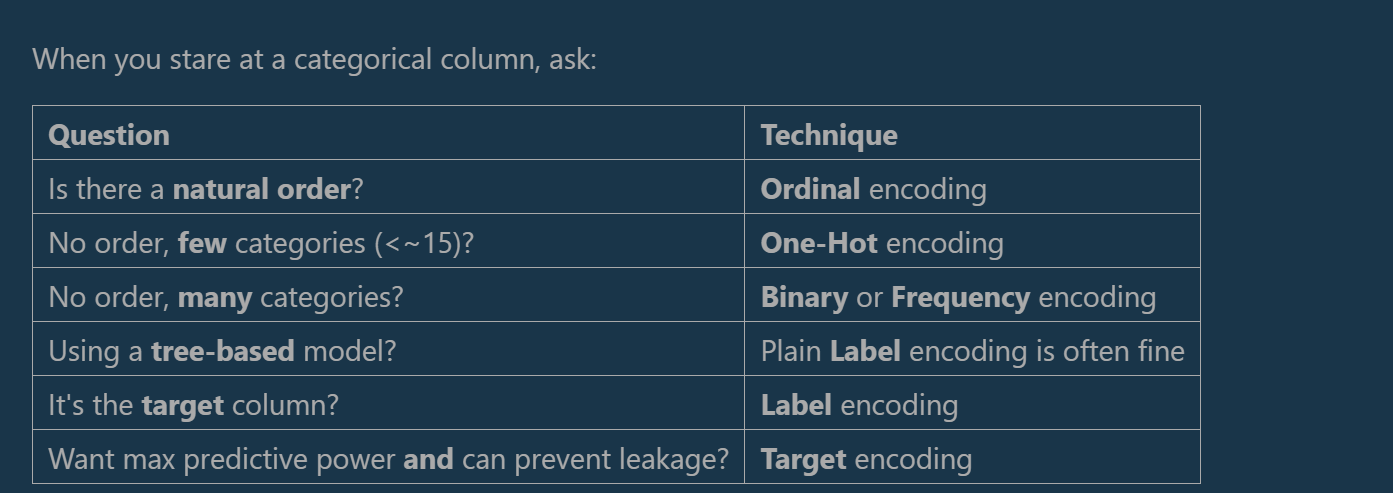

## Recap

You now have a full toolkit:

- **Label** → simple integers; fine for targets & trees, dangerous elsewhere (order trap).
- **Ordinal** → deliberate, meaningful order.
- **One-Hot** → binary columns, no fake order; watch dimensionality.
- **Binary** → compact alternative for many categories.
- **Target** → predictive but leakage-prone; use smoothing + CV.
- **Frequency** → cheap, count-based signal.

Next steps to explore: put these inside a scikit-learn `ColumnTransformer` + `Pipeline`, and try the `category_encoders` library for production-ready Binary and Target encoders.